
#  Flight Delay Predictor – Project Report By: Zachary Kaiser

*This project aims to predict flight delays using engineered features derived from historical U.S. airline performance data. Rather than using raw flight records, this model relies on monthly-aggregated summaries at the carrier-airport level, reducing noise while enabling generalizable prediction. The final model returns a binary prediction (delayed or not) using only three user inputs: carrier, airport, and month.*



## 1. Data Source

> **[Kaggle Dataset – Airline Delay](https://www.kaggle.com/datasets/sriharshaeedala/airline-delay)**  
> Author: *Sriharsha Eedala*

The dataset provides monthly flight statistics by carrier and airport, including:

- Number of flights
- Delay counts by cause (weather, NAS, late aircraft, etc.)
- Total minutes of delay
- Cancellations and diversions

**No external data sources were used.** The entire pipeline was derived from and limited to this single dataset.



## 2. Objective

To create a predictive model that determines whether a given **carrier-airport-month** combination is likely to experience significant delays. The model is built to:

- Accept only: `carrier`, `airport`, and `month` as input  
- Return: A **binary classification** (`is_delayed = 1` or `0`)  
- Avoid: One-hot encoding or label encoding due to shear amount of unique combinations – use only numerically engineered features tailored to the target input variables



## 3. Data Wrangling

`FDP - Data Wrangling.ipynb`

Steps taken:

- Loaded raw CSV and reviewed shape, types, and nulls
- Observed that NaNs occurred when a carrier did not fly to an airport during a given month
- Rows with nulls were dropped, as they represent non-events with no meaningful contribution
- Final cleaned data retained only operational flights with recorded performance metrics

Output: `airline_delay_cleaned.csv`



## 4. Exploratory Data Analysis

`FDP - EDA.ipynb`

Exploration was structured around **carrier, airport, and seasonal behaviors**.

Key insights:

- **Carrier Trends**: Some carriers had consistently high delay or cancel rates
- **Airport Volume**: High-traffic airports (like ATL, ORD) had higher variability
- **Monthly Seasonality**: Delay rates spiked during holidays and summer
- **Delay Cause Patterns**:
  - NAS and Late Aircraft delays dominate
  - Weather delays are spiky and unpredictable
  - Security-related delays are rare and negligible


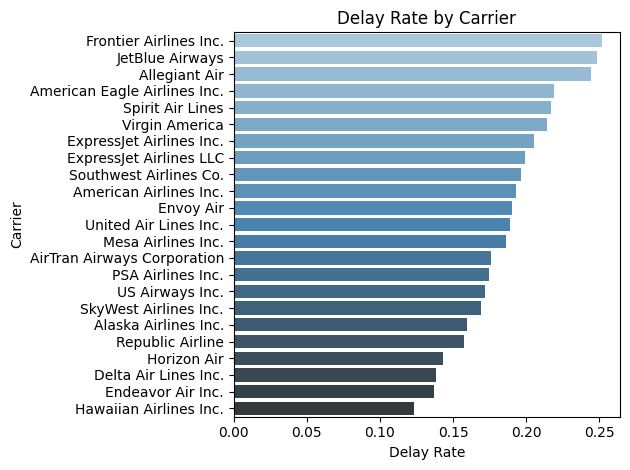

Above image is the top carriers that had a significant delay rate, Delay rate ended up being one of my metrics for the binary classification on wheather or not a flight would be delayed

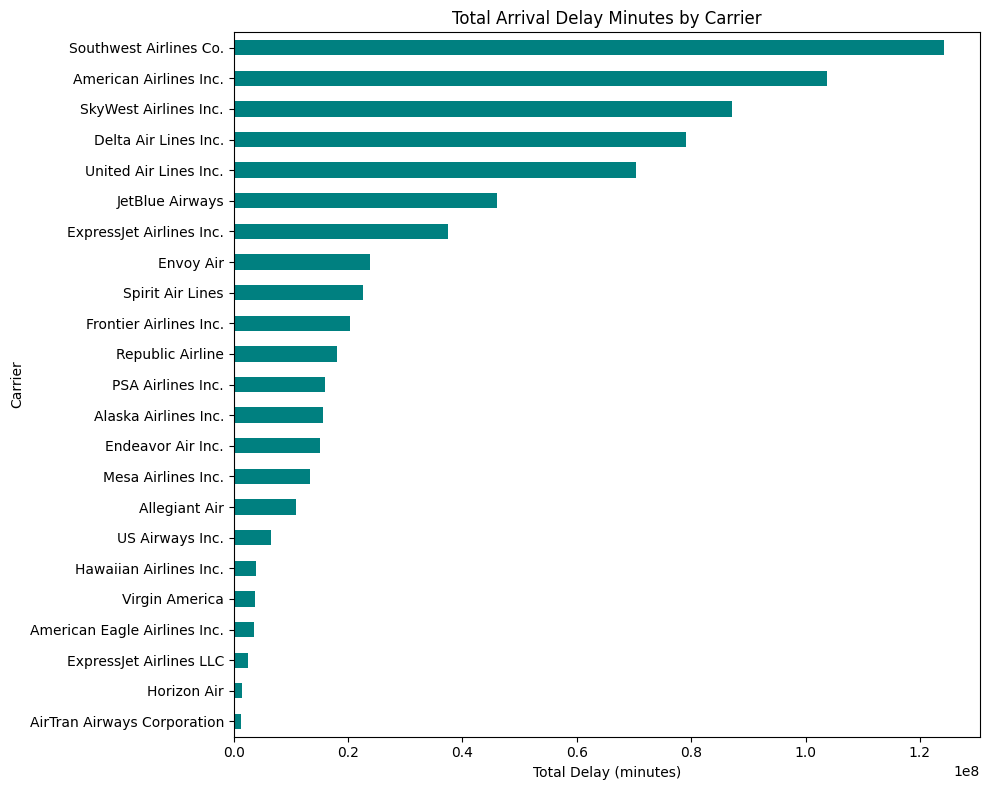

Interesting contrast to point out between the two plots above, frontier who had one of the highest delay rates was acutally low compared to other airlines on total delay time. Drew insight on some carriers may have less delays but when delays do occur it tends to be more significant. 

Below are some additional figures that I feel really put some information into perspective which is cancelation rates and delay rates you can see that the larger airports i.e New York and Chicago have some of the highest cancelation rates and delay rates which put them in a catagory almost of their own. 

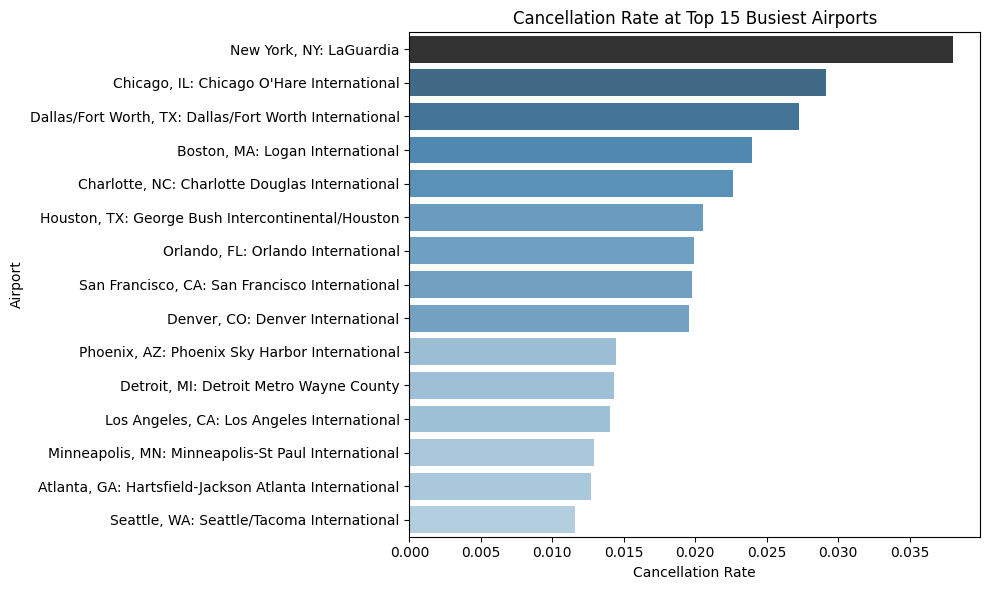
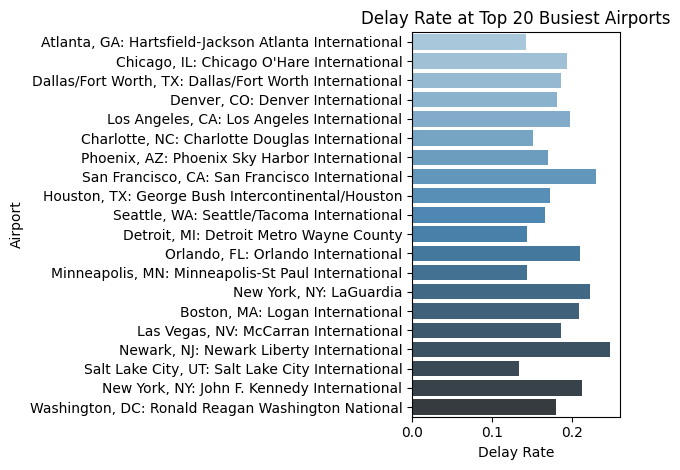


Insight into the causes of airport delays showed a remarkable amount of NAS delays for LaGuardia which due to its location and amount of flights explain the delay caused by issues with ATC (Air Traffic Contoller)

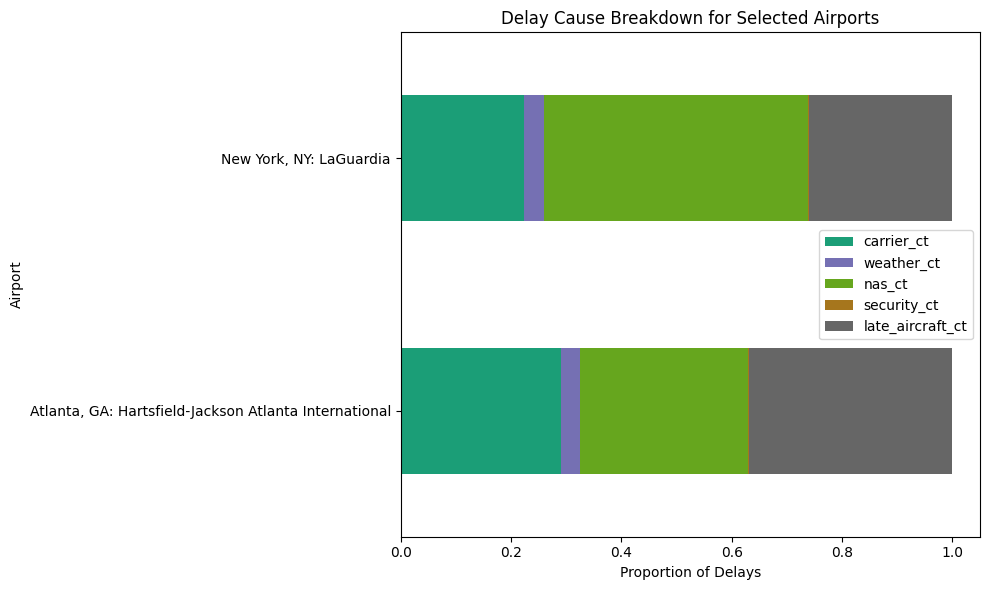


One of the Final Key Takeaways from my EDA was seasonal trends Taking a look at the figure below you can see the seasonal delays that occure with the top 6 airports in the Country. 

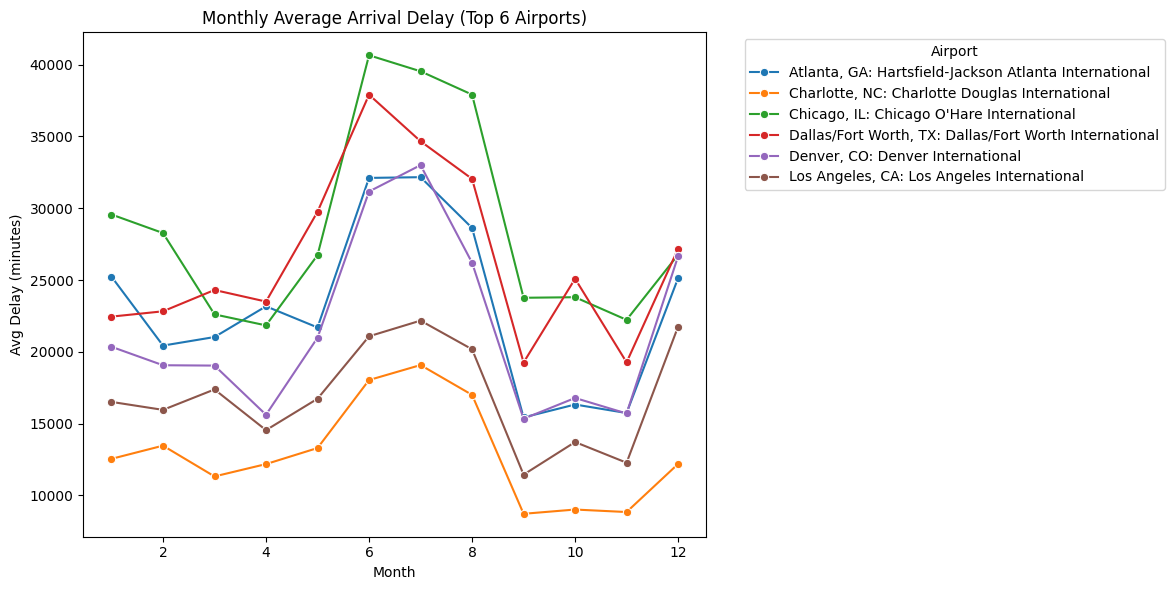


## 5. Feature Engineering & Preprocessing

`FDP - Preprocessing and Training.ipynb`

No categorical encodings were used. Instead, features were **entirely engineered numerically** from the cleaned dataset:

Creating the numerical features to capter carrier and airport specific trends and features opposed to One-hot encoding the catagorical features was due to the shear volumne of uniqe catagorical combinations that added a large amount of noise and risk of overfit to my data, creating the numerical pre-computed rates allowed for an easier input to my pipeline and avoided the need for dummy variables or handleing the immense amount of catagorical options.

### Features Created:

| Feature | Description |
|--------|-------------|
| `delay_rate` | `arr_del15 / arr_flights` |
| `cancel_rate` | `arr_cancelled / arr_flights` |
| `divert_rate` | `arr_diverted / arr_flights` |
| `weather_pct`, `nas_pct`, `security_pct`, `carrier_pct`, `late_aircraft_pct` | Delay minutes as a percent of total delay |
| `traffic_volume` | Raw `arr_flights` per carrier-airport-month |
| `month` | Extracted from date column |
| `season` | Mapped manually from month (e.g., Winter = Jan, Feb, Dec) |
| `carrier_airport_delay_rate`, `carrier_airport_volume` | Airport and carrier pairs


#### Identifying our Target Variable:
The original dataset defined a flight as delayed if it was delayed over 15 minutes, which labeled over 96% of the data as delayed, which is too imbalanced to be useful. I redefined is_delayed using a more balanced approach based on delay rate and total delay time, as you can see in the figure below I compared the percentage of the data set that would be catagorized as delayed I ended up choosing a delay rate > 0.15 and a total delay greater > 15 minutes, this catagorized 58.5% of the data set as delayed. 

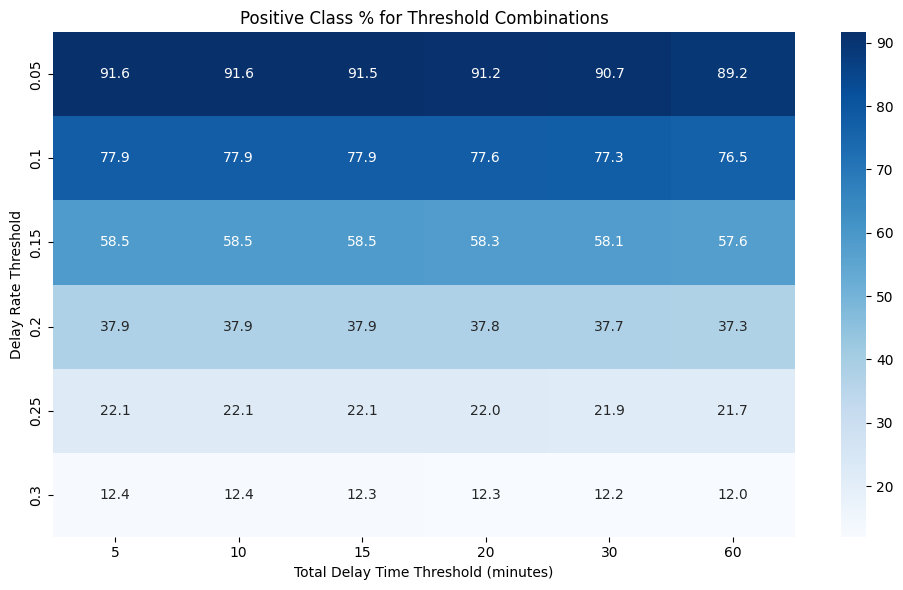

> `is_delayed = 1` if  
> - `delay_rate ≥ 0.15`  
> &  
> - `total delay minutes ≥ 15`  

Else, `is_delayed = 0`



## 6. Modeling

`FDP - Modeling.ipynb`

### Models Tested:
- **Logistic Regression**
- **Random Forest Classifier**
- **XGBoost Classifier** Final Production Model Selected

### Train/Test Split:
- 80/20 stratified split on `is_delayed`
- All features passed in numeric format

### Grid Search Tuning Method:
- Used `GridSearchCV` to tune `XGBoost`, `Logistic Regression` and `Random Forest Classifier`:
```python

Final Tuned Model Parameters XGBoost!

XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)
```

Final model was saved as `models/xgboost_model.pkl`



## 7. Evaluation

### Model Performance:

| Model              | AUC-ROC | Accuracy | F1 Score |
|-------------------|---------|----------|----------|
| Logistic Regression | ~0.71   | (0.731) Moderate | (0.784)Lower    |
| Random Forest       | ~0.84   | (0.798) Strong   | (0.836)High     |
| **XGBoost (Final)** | **~0.86** | **(0.807) Best**  | **(0.841) Best**  |

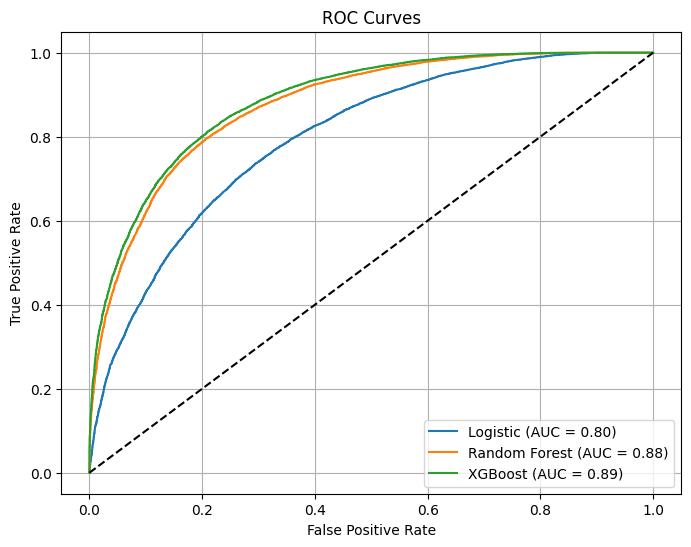

### Feature Importance:

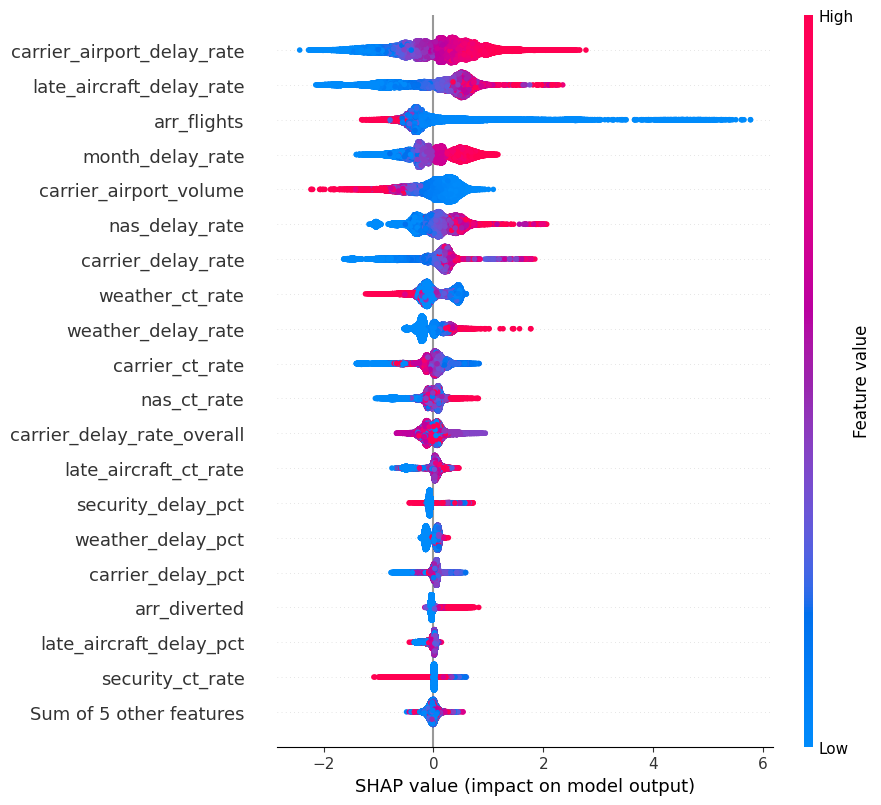


## 8. Prediction Pipeline

Inputs:

```python
predict_delay(carrier="Delta Air Lines", airport="ATL", Month = "9")
```

Internally, the pipeline:

- Maps carrier/airport/month to precomputed features
- Passes those features to XGBoost
- Returns a probability of delay (thresholded at 0.5)

Below are two sample predictions showing how the model behaves on contrasting inputs. These are visualized with SHAP to provide insight into which features drove the predictions. 

- Southwest whith high historical delays and Phoenix in the summer tie to a high likely hood for delays 
- Alaska Airlines with a good track record at Portland and in october results in a low risk of delay probability

# Cairrier (WN)	Airport(PHX) Month (8) Prediction (95.050003)

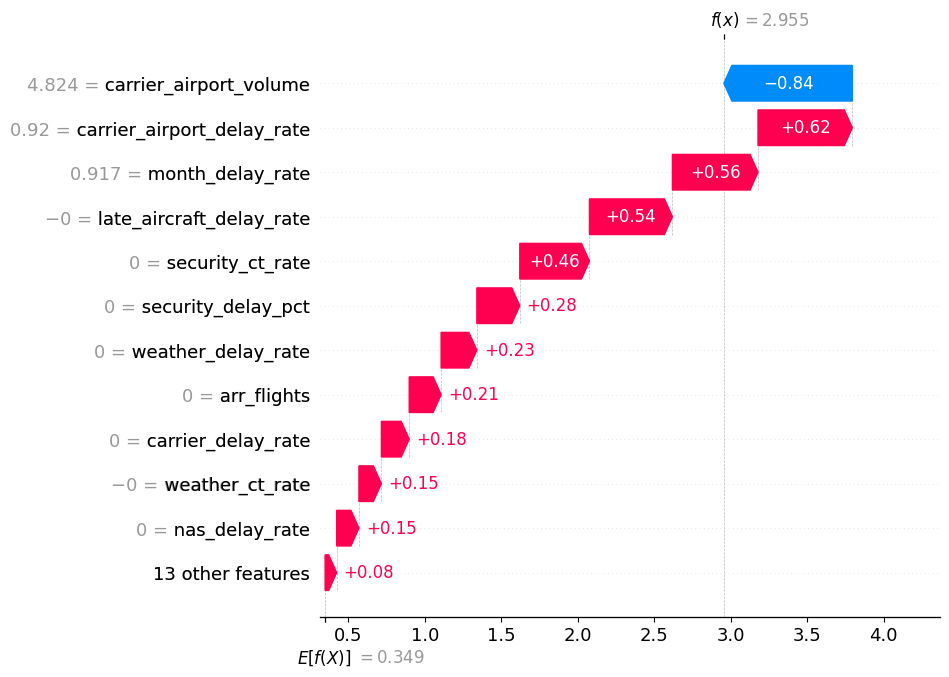

# Cairrier (AS)	Airport (PDX)	Month (10) Prediction (16.020000)

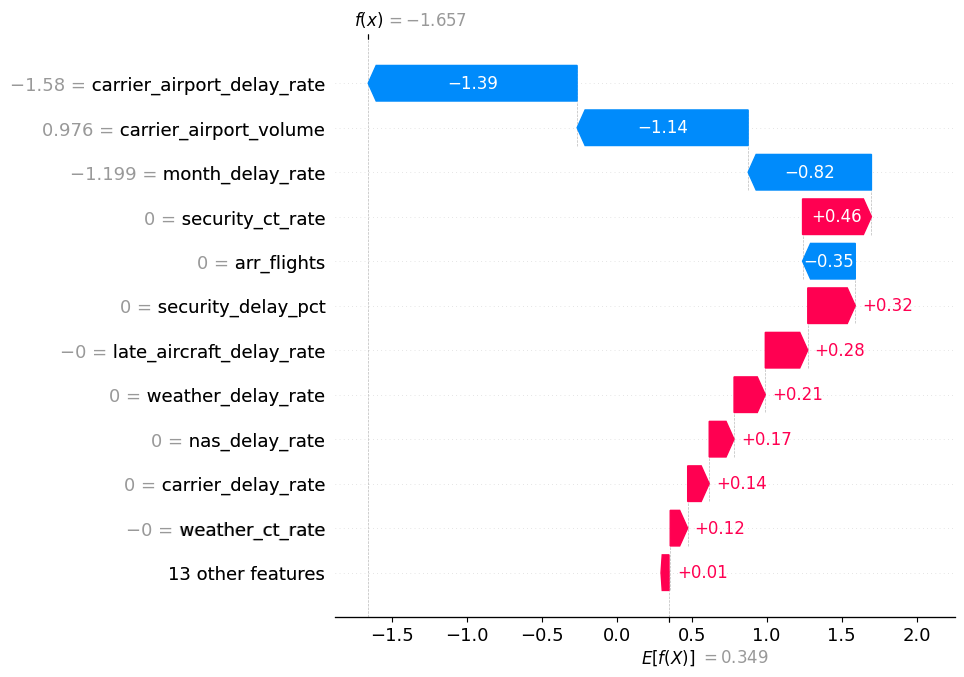


## 9. Final Thoughts and Future Goals
The Flight Delay Predictor project successfully demonstrates how historical flight performance data can be leveraged to make meaningful predictions about future delays. The current model performs well using only three raw inputs (carrier, airport, and month), which are mapped to engineered numerical features that summarize trends in delay rates, causes, and traffic volume.

### Reflections:
Model performance was strong, especially considering the limited granularity of the dataset. Monthly summaries smoothed out some of the nuance seen in real-world delays, particularly those caused by holidays or unusual events.

One major opportunity for improvement would be the incorporation of real-time weather data. Being able to factor in major forecast events — such as winter storms or hurricanes this would allow the model to better reflect short-term risks.

More fine-grained temporal data (i.e., weekly or per-flight-level) would open the door to richer pattern discovery — like day-of-week, time-of-day, or event-based delays, however, would require significantly more data wrangling.

### Future Goals:
- Enhance feature engineering by integrating more dynamic and temporal variables (e.g., holidays, weather alerts, flight times).

- Deploy the model as a lightweight web application or dashboard, allowing users to:

- Select upcoming flights via dropdown menus

- View predicted on-time probabilities

- Understand key risk factors (i.e., weather, carrier behavior)

- Enable continuous learning, so the model can retrain as new data is added monthly, maintaining its predictive strength over time.

Overall, this project provides a strong foundation — one that could evolve into a real-world planning tool for travelers, airlines, or even airport operations teams. With continued refinement, it has the potential to offer timely, contextual insights that improve how we all plan and manage air travel.


## 10. Credits

- **Sriharsha Eedala** for the [Kaggle dataset](https://www.kaggle.com/datasets/sriharshaeedala/airline-delay)
- My Excellent Springboard Mentor **David Lara-Arango**
- Python stack: `pandas`, `xgboost`, `scikit-learn`, `matplotlib`, `seaborn`
